# Exercício 4 — Sua própria coleta com Zeeschuimer

Este exercício repete o fluxo da aula (instalar → coletar → exportar → explorar → nuvens de palavras → downloads), com um recorte escolhido por você, e aprofunda a parte de métricas, que na aula ficou só no superficial.

Na aula você viu a leitura do CSV de duas formas, com `csv` e com `pandas`. Aqui em diante, use sempre o `pandas`: ele deixa cálculos de métrica (média, máximo, agrupamento por autor) bem mais diretos do que fazer isso na mão com listas.

Antes de TUDO, copie a pasta `exercicios/` para dentro da sua pasta de entregas (`extracao-dados-trabalhos-SeuNome`, lembrando que é o SEU nome, não o meu 🙃), dentro de uma pasta `04-coleta-redes` em `projetos/`.

## Preparação do ambiente

Como este notebook vai morar numa pasta própria (dentro da sua pasta de entregas, fora do material do curso), crie o ambiente e instale as dependências de novo, dentro da pasta `exercicios/` copiada:

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

Se o `uv` não funcionar, use `pip install -r requirements.txt` com o ambiente já ativado.

## Parte 0 — Escolha do recorte

Escolha, dentro do que foi combinado em aula (plataforma e tipo de recorte permitidos), um alvo específico para a sua coleta: uma hashtag, um perfil público ou uma busca. Registre aqui antes de coletar:

**Plataforma:**

> Tiktok

**Recorte escolhido (hashtag, perfil ou busca):**

> #futevolei

**ATENÇÃO:** o recorte precisa ser público e caber no que foi combinado em aula. Nada de perfis privados, conteúdo de menores de idade ou qualquer coisa fora do escopo demonstrativo.

## Parte 1 — Coleta e exportação

Com o Firefox e o Zeeschuimer já instalados (seções 3 e 4 da aula), repita o fluxo:

1. Abra o recorte escolhido na Parte 0 e role o feed normalmente por alguns minutos.
2. Confira no ícone do Zeeschuimer que os itens estão sendo capturados.
3. Exporte a coleta (painel da extensão → opção de exportação). O arquivo vem em CSV, separado por `;`.
4. Renomeie o arquivo para `exportacao.csv` e salve dentro de `exercicios/dados/` (crie a pasta se não existir).

**OBS:** não precisa de uma coleta grande. Poucos minutos de rolagem, com algumas centenas de itens capturados, já são suficientes para o exercício. Máximo de 500.

## Parte 2 — Quais são as variáveis?

Antes de sair usando o arquivo, explore o cabeçalho: rode a célula abaixo e leia com calma as colunas e os valores do primeiro item.

In [1]:
import pandas as pd

df = pd.read_csv("dados/exportacao.csv", sep=";")

print(f"Linhas coletadas: {len(df)}")
df.iloc[0]

Linhas coletadas: 259


collected_from_url        https://www.tiktok.com/search?q=futevolei&t=17...
id                                                      7616109055207050514
thread_id                                               7616109055207050514
author                                                     futevolei.brasil
author_full                                                FUTEVOLEI.BRASIL
author_followers                                                      53500
author_likes                                                           1603
author_videos                                                           821
author_avatar             https://p16-common-sign.tiktokcdn.com/tos-mali...
body                        #futevoleibrasil #foryoupage #viral @JOAO ET 👽 
stickers                                                   @FutevoleiBrasil
timestamp                                               2026-03-11 21:13:00
unix_timestamp                                                   1773263580
is_duet     

Escolha cinco colunas do seu arquivo e descreva, com suas palavras, o que cada uma representa (use a tabela da Aula 4 como referência para as colunas em comum, mas repare que a sua plataforma pode ter colunas diferentes):

**Coluna 1:**

> 

**Coluna 2:**

> Escreva aqui.

**Coluna 3:**

> Escreva aqui.

**Coluna 4:**

> Escreva aqui.

**Coluna 5:**

> Escreva aqui.

## Parte 3 — Nuvens de palavras

Repita as duas nuvens da aula: uma para o texto dos posts, outra para as hashtags. Ajuste o nome da coluna de texto se a sua plataforma usar um nome diferente de `body`.

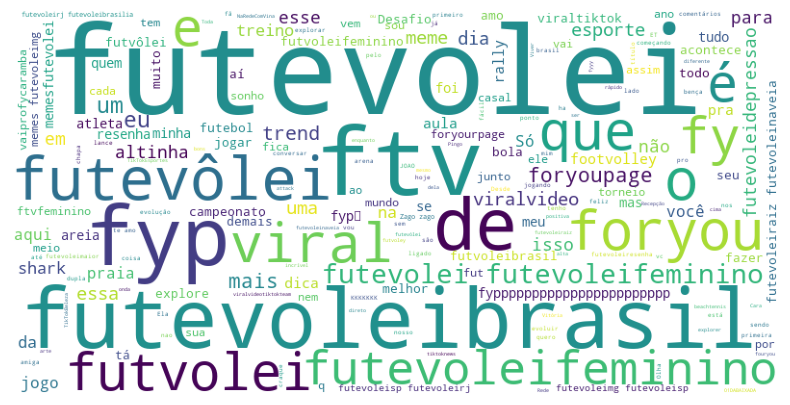

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_completo = " ".join(df["body"].dropna())

nuvem = WordCloud(width=800, height=400, background_color="white").generate(texto_completo)

plt.figure(figsize=(10, 5))
plt.imshow(nuvem)
plt.axis("off")
plt.show()

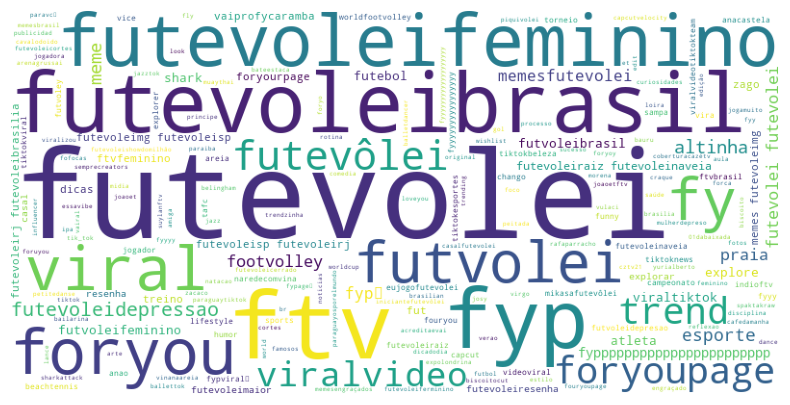

In [3]:
hashtags_completo = " ".join(df["hashtags"].dropna().str.replace(",", " "))

nuvem_hashtags = WordCloud(width=800, height=400, background_color="white").generate(hashtags_completo)

plt.figure(figsize=(10, 5))
plt.imshow(nuvem_hashtags)
plt.axis("off")
plt.show()

## Parte 4 — Baixando thumbnails e vídeos

Repita os downloads da aula. Ajuste os nomes de coluna se necessário (algumas plataformas não têm `video_url`, só imagem).

In [4]:
import urllib.request
from pathlib import Path

pasta_thumbnails = Path("dados/thumbnails")
pasta_thumbnails.mkdir(parents=True, exist_ok=True)

primeiras_linhas = df.head(20)

for linha in primeiras_linhas.itertuples():
    if pd.notna(linha.thumbnail_url):
        destino = pasta_thumbnails / f"{linha.id}.jpg"
        urllib.request.urlretrieve(linha.thumbnail_url, destino)

print(f"Thumbnails salvas em {pasta_thumbnails}")

HTTPError: HTTP Error 403: Forbidden

In [5]:
pasta_videos = Path("dados/videos")
pasta_videos.mkdir(parents=True, exist_ok=True)

primeiras_linhas = df.head(5)

for linha in primeiras_linhas.itertuples():
    if pd.notna(linha.video_url):
        destino = pasta_videos / f"{linha.id}.mp4"
        urllib.request.urlretrieve(linha.video_url, destino)

print(f"Vídeos salvos em {pasta_videos}")

HTTPError: HTTP Error 403: Forbidden

## Parte 5 — Métricas, com mais profundidade

Na aula, as métricas ficaram só no superficial (vídeo mais curtido, média geral, autor mais frequente). Aqui a ideia é ir um pouco além, sempre com `pandas`: colunas, `.mean()`, `.max()`, `.groupby()`.

### 5.1 — Estatísticas de cada métrica de engajamento

Para `likes`, `comments`, `shares` e `plays`, calcule o mínimo, o máximo e a média. Complete o código: falta imprimir as estatísticas de `comments` e `shares`, do mesmo jeito que `likes` e `plays` já estão prontos.

In [4]:
print(f"Curtidas: mínimo {df['likes'].min()}, máximo {df['likes'].max()}, média {df['likes'].mean():.1f}")
print(f"Visualizações: mínimo {df['plays'].min()}, máximo {df['plays'].max()}, média {df['plays'].mean():.1f}")
# print(f"Comentários: mínimo {...}, máximo {...}, média {...}")
# print(f"Compartilhamentos: mínimo {...}, máximo {...}, média {...}")

Curtidas: mínimo 2, máximo 3200000, média 57944.4
Visualizações: mínimo 128, máximo 40100000, média 700114.9


### 5.2 — Taxa de engajamento por vídeo

Curtidas em número absoluto favorecem quem tem mais visualizações. Uma forma de comparar vídeos de forma mais justa é calcular uma taxa: `(curtidas + comentários + compartilhamentos) / visualizações`. Complete a linha marcada, criando essa conta como uma nova coluna do `df`.

In [19]:
df_com_visualizacoes = df[df["plays"] > 0].copy()

df_com_visualizacoes["taxa_engajamento"] = (
    df_com_visualizacoes["likes"] + df_com_visualizacoes["comments"] + df_com_visualizacoes["shares"]
) / df_com_visualizacoes["plays"]

media_engajamento = df_com_visualizacoes["taxa_engajamento"].mean()
print(f"Taxa média de engajamento: {media_engajamento:.2%}")


Taxa média de engajamento: 9.66%


In [ ]:
df[["curtidas" + "comentarios" + "compartilhamentos"]].isna().sum()

**O que observar:** vídeos com poucas visualizações podem ter taxa de engajamento alta mesmo com poucas curtidas em número absoluto. Compare o vídeo mais curtido em número absoluto (que você calculou na aula) com o vídeo de maior taxa de engajamento, eles costumam ser diferentes.

### 5.3 — Curtidas médias por autor, em gráfico

Agrupe as linhas por autor com `df.groupby("author")`, calcule a média de curtidas de cada um, e monte um gráfico de barras com os 10 autores que mais apareceram na sua coleta.

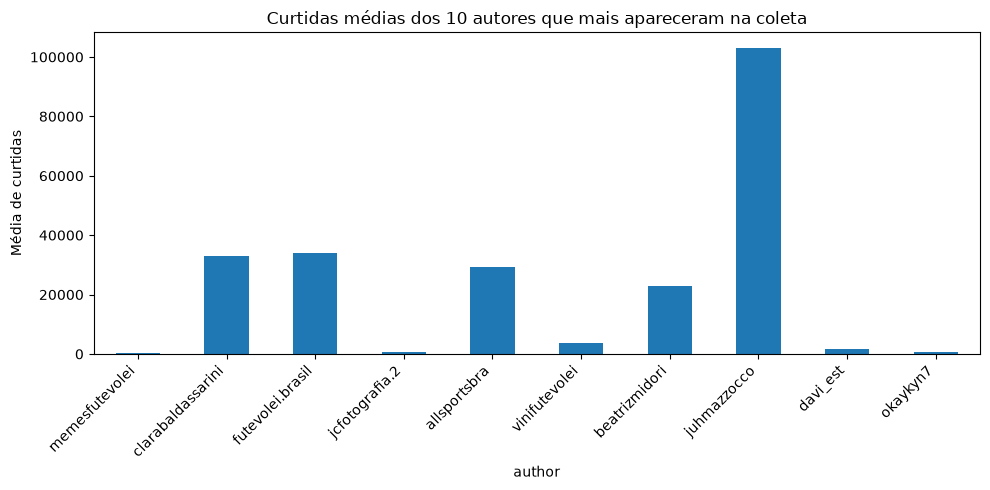

In [20]:
top_autores = df["author"].value_counts().head(10)

media_por_autor = df.groupby("author")["likes"].mean()
medias_dos_top_autores = media_por_autor[top_autores.index]

plt.figure(figsize=(10, 5))
medias_dos_top_autores.plot(kind="bar")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Média de curtidas")
plt.title("Curtidas médias dos 10 autores que mais apareceram na coleta")
plt.tight_layout()
plt.show()

### 5.4 — Sua pergunta

Formule uma pergunta própria sobre a sua coleta (por exemplo: "vídeos com música original têm mais engajamento que os com áudio de terceiros?", "há relação entre número de hashtags usadas e visualizações?") e responda com código, reaproveitando o que fez até aqui.

**Pergunta escolhida:**

> Escreva aqui.

**Resposta (com o código usado):**

In [ ]:
# escreva aqui o código da sua pergunta

**Interpretação, em texto:**

> Escreva aqui o que os números/gráfico mostram, e o que eles não permitem concluir.

## Parte 6 — Documentando a coleta

Crie `projetos/04-coleta-redes/README.md` (na sua pasta de entregas, não aqui) e responda:

**Fonte (plataforma e recorte coletado):**

> Escreva aqui.

**Período da coleta (data e hora de início e fim):**

> Escreva aqui.

**Consulta/coleta realizada (o que exatamente foi navegado: hashtag, perfil, busca):**

> Escreva aqui.

**Campos disponíveis no arquivo exportado (cole a lista impressa na Parte 2):**

> Escreva aqui.

**Limites éticos do conjunto (o que esse conjunto NÃO permite concluir, e quais cuidados foram tomados na coleta):**

> Escreva aqui.

## Parte 7 — Conferência final

Antes de considerar a entrega concluída, confira:

- [ ] O arquivo `exportacao.csv`, as thumbnails e os vídeos estão em `projetos/04-coleta-redes/exercicios/dados/` (ou pasta equivalente da sua entrega), e essa pasta está no `.gitignore`.
- [ ] A Parte 2 rodou sem erro e mostrou o número de itens e os campos disponíveis, com cinco colunas descritas.
- [ ] As duas nuvens de palavras (texto e hashtags) foram geradas.
- [ ] Os downloads de thumbnails e vídeos rodaram sem erro (ou os erros foram entendidos e ignorados, seção 15 da aula).
- [ ] A Parte 5 está completa: estatísticas das quatro métricas, taxa de engajamento, gráfico de curtidas por autor e sua pergunta própria respondida e interpretada.
- [ ] `projetos/04-coleta-redes/README.md` responde às quatro perguntas da Parte 6.
- [ ] O recorte coletado é público e está dentro do combinado em aula.
- [ ] Esse notebook está copiado dentro de `projetos/04-coleta-redes/` na sua pasta de entregas.
- [ ] Você já fez `git add`, `git commit` e `git push` dessa entrega (Aula 3, se precisar relembrar os comandos).